# ClimateGuard AI v3.0 - Rainfall Prediction

This notebook covers training ML models for rainfall prediction. 

## 1. Import Libraries

In [1]:
## 2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.models.rainfall_prediction import RainfallPredictor
from src.models.model_evaluation import ModelEvaluator

# Ensure plots are displayed inline
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Climate Zones Data

In [2]:
# Load data from climate profiling step
df = pd.read_csv('../data/processed/07_climate_zones.csv')
print(f"Data loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")

Data loaded: (119398, 84)
Columns: 84


## 3. Prepare Features and Target for Rainfall Prediction

In [3]:
# Select numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove climate zone and rain target columns from features
feature_cols = [
    col for col in numerical_cols
    if col not in ['climate_zone', 'rain_target']
]

# Create target: rainfall > 0
if 'precip_mm' in df.columns:
    df['rain_target'] = (df['precip_mm'] > 0).astype(int)

    y = df['rain_target']
    X = df[feature_cols].fillna(0)

    print(f"Features: {len(X.columns)}")
    print("Target distribution:")
    print(y.value_counts())

    print(f"\nRainfall percentage: {y.mean() * 100:.2f}%")

else:
    print("Precipitation column not found.")
    print("Available columns:")
    print(df.columns.tolist())

Features: 62
Target distribution:
rain_target
0    104510
1     14888
Name: count, dtype: int64

Rainfall percentage: 12.47%


## 4. Initialize Rainfall Predictor

In [4]:
predictor = RainfallPredictor(X, y)
print("Rainfall predictor initialized")

Rainfall predictor initialized


## 5. Train Logistic Regression

In [5]:
print("Training Logistic Regression...")
lr_metrics = predictor.train_logistic_regression(C=1.0, max_iter=1000)
print(f"Accuracy: {lr_metrics['accuracy']:.4f}")
print(f"F1 Score: {lr_metrics['f1_score']:.4f}")
print(f"ROC AUC: {lr_metrics['roc_auc']:.4f}")

Training Logistic Regression...


INFO:src.models.rainfall_prediction:Data preprocessed and split
INFO:src.models.rainfall_prediction:Logistic Regression trained - Accuracy: 0.9842


Accuracy: 0.9842
F1 Score: 0.9338
ROC AUC: 0.9974


## 6. Train Decision Tree

In [6]:
print("Training Decision Tree...")
dt_metrics = predictor.train_decision_tree(max_depth=10, min_samples_split=5)
print(f"Accuracy: {dt_metrics['accuracy']:.4f}")
print(f"F1 Score: {dt_metrics['f1_score']:.4f}")
print(f"ROC AUC: {dt_metrics['roc_auc']:.4f}")

Training Decision Tree...


INFO:src.models.rainfall_prediction:Data preprocessed and split
INFO:src.models.rainfall_prediction:Decision Tree trained - Accuracy: 1.0000


Accuracy: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000


## 7. Train Random Forest

In [7]:
print("Training Random Forest...")
rf_metrics = predictor.train_random_forest(n_estimators=100, max_depth=10)
print(f"Accuracy: {rf_metrics['accuracy']:.4f}")
print(f"F1 Score: {rf_metrics['f1_score']:.4f}")
print(f"ROC AUC: {rf_metrics['roc_auc']:.4f}")

Training Random Forest...


INFO:src.models.rainfall_prediction:Data preprocessed and split
INFO:src.models.rainfall_prediction:Random Forest trained - Accuracy: 1.0000


Accuracy: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000


## 8. Train Gradient Boosting

In [8]:
print("Training Gradient Boosting...")
gb_metrics = predictor.train_gradient_boosting(n_estimators=100, learning_rate=0.1)
print(f"Accuracy: {gb_metrics['accuracy']:.4f}")
print(f"F1 Score: {gb_metrics['f1_score']:.4f}")
print(f"ROC AUC: {gb_metrics['roc_auc']:.4f}")

Training Gradient Boosting...


INFO:src.models.rainfall_prediction:Data preprocessed and split
INFO:src.models.rainfall_prediction:Gradient Boosting trained - Accuracy: 1.0000


Accuracy: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000


## 9. Select Best Model

In [9]:
best_model = predictor.select_best_model(metric='f1_score')
print(f"Best model selected: {best_model}")

INFO:src.models.rainfall_prediction:Best model selected: decision_tree


Best model selected: decision_tree


## 10. Print Model Training Report

In [10]:
predictor.print_report()

RAINFALL PREDICTION MODEL REPORT

LOGISTIC_REGRESSION:
  Accuracy: 0.9842
  Precision: 0.9779
  Recall: 0.8936
  F1 Score: 0.9338
  ROC AUC: 0.9974

DECISION_TREE:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  ROC AUC: 1.0000

RANDOM_FOREST:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  ROC AUC: 1.0000
  Top 5 Feature Importances:
    precip_mm: 0.5558
    cloud: 0.1983
    humidity: 0.0512
    visibility_km: 0.0274
    air_quality_PM10: 0.0225

GRADIENT_BOOSTING:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  ROC AUC: 1.0000
  Top 5 Feature Importances:
    precip_mm: 1.0000
    longitude: 0.0000
    temperature_celsius: 0.0000
    air_quality_Ozone: 0.0000
    week_of_year_cos: 0.0000

Best Model: decision_tree



## 11. Evaluate Best Model

In [11]:
# Get predictions from best model
y_pred = predictor.best_model.predict(predictor.X_test)
y_pred_proba = predictor.best_model.predict_proba(predictor.X_test)[:, 1]

# Evaluate
evaluator = ModelEvaluator(predictor.y_test, y_pred, y_pred_proba)
evaluator.generate_evaluation_report()
evaluator.print_report()

MODEL EVALUATION REPORT

CLASSIFICATION METRICS:
  Accuracy: 0.1247
  Precision (weighted): 0.0156
  Recall (weighted): 0.1247
  F1 Score (weighted): 0.0277
  Precision (binary): 0.1247
  Recall (binary): 1.0000
  F1 Score (binary): 0.2218
  ROC AUC: 0.5000

CONFUSION MATRIX:
  [0, 20902]
  [0, 2978]



## 12. Plot Confusion Matrix

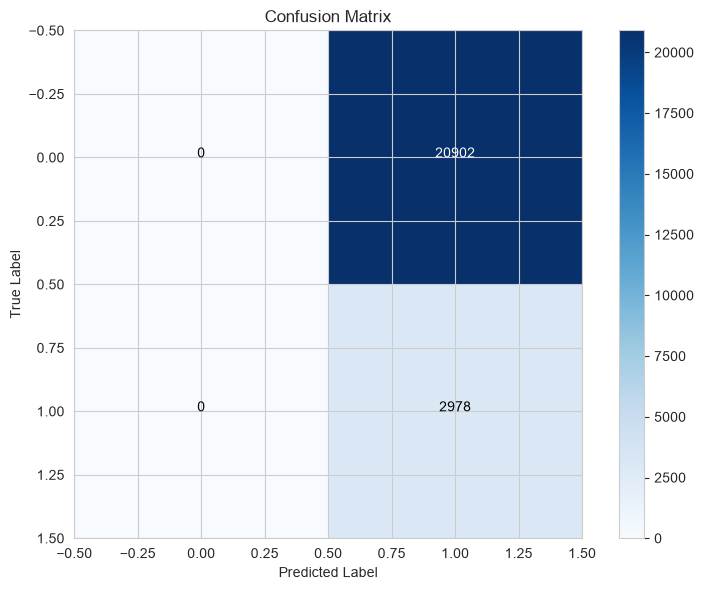

INFO:src.models.model_evaluation:Confusion matrix displayed


Confusion matrix displayed


In [12]:
## 12. Plot Confusion Matrix
evaluator.plot_confusion_matrix()
print("Confusion matrix displayed")

## 13. Plot ROC Curve

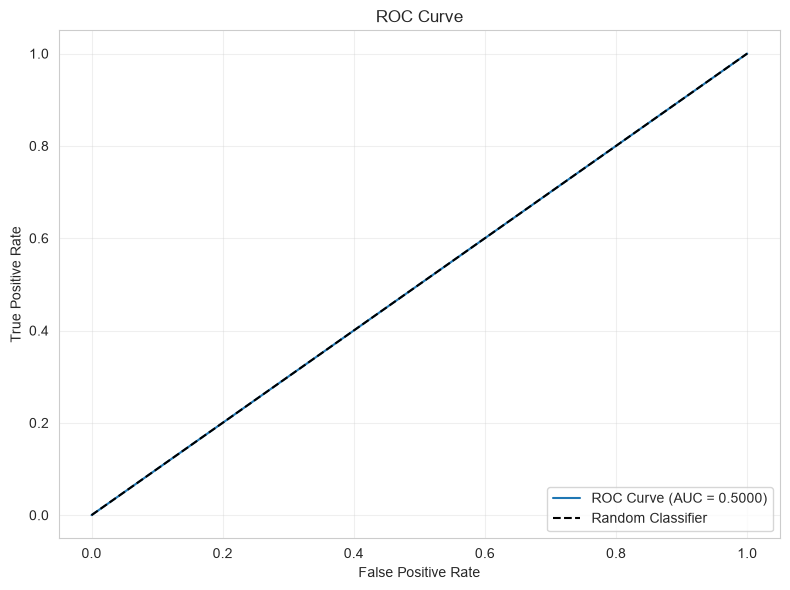

INFO:src.models.model_evaluation:ROC curve displayed


ROC curve displayed


In [13]:
## 13. Plot ROC Curve
evaluator.plot_roc_curve()
print("ROC curve displayed")

## 14. Plot Precision-Recall Curve

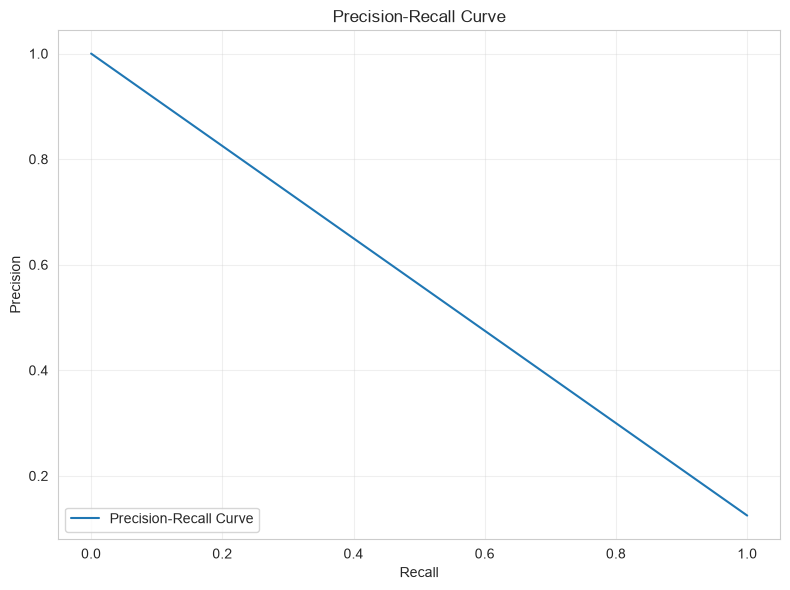

INFO:src.models.model_evaluation:PR curve displayed


PR curve displayed


In [14]:
## 14. Plot Precision-Recall Curve
evaluator.plot_precision_recall_curve()
print("PR curve displayed")

## 15. Feature Importance (if Random Forest or Gradient Boosting)

In [15]:
if predictor.best_model_name in ['random_forest', 'gradient_boosting']:
    report = predictor.get_model_report()
    if 'feature_importance' in report[predictor.best_model_name]:
        importance = report[predictor.best_model_name]['feature_importance']
        
        # Plot feature importance
        plt.figure(figsize=(12, 8))
        sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:15]
        features, scores = zip(*sorted_features)
        plt.barh(range(len(features)), scores)
        plt.yticks(range(len(features)), features)
        plt.xlabel('Feature Importance')
        plt.title('Top 15 Feature Importances - Rainfall Prediction')
        plt.tight_layout()
        plt.show()
        print("Feature importance plot displayed")

## 16. Save Best Model

In [16]:
# Create trained_models directory if not exists
os.makedirs('../trained_models', exist_ok=True)

# Save the best model
predictor.save_model(predictor.best_model_name, '../trained_models/02_rainfall_model.pkl')
print(f"Best model saved to ../trained_models/02_rainfall_model.pkl")

INFO:src.models.rainfall_prediction:Model decision_tree saved to ../trained_models/02_rainfall_model.pkl


Best model saved to ../trained_models/02_rainfall_model.pkl


## 17. Test Prediction on Sample Data

In [17]:
# Test on a sample
sample = X.iloc[[0]]
prediction, probability = predictor.predict(sample)

print(f"Sample prediction: {prediction[0]}")
print(f"Rain probability: {probability[0]:.4f}")
print(f"Actual: {y.iloc[0]}")

Sample prediction: 0
Rain probability: 0.0000
Actual: 0


## 18. Save Data with Rainfall Prediction 

In [18]:
df.to_csv('../data/processed/08_rainfall_predictions.csv', index=False)
print("\nData with rainfall predictions saved to ../data/processed/08_rainfall_predictions.csv")


Data with rainfall predictions saved to ../data/processed/08_rainfall_predictions.csv


## Summary
 
In this notebook, we:
1. Loaded the climate zones data
2. Prepared features and target for rainfall prediction
3. Trained Logistic Regression model
4. Trained Decision Tree model
5. Trained Random Forest model
6. Trained Gradient Boosting model
7. Selected the best model based on F1 score
8. Evaluated the best model
9. Generated confusion matrix, ROC curve, and PR curve
10. Analyzed feature importance
11. Saved the best model for deployment

Next: Heatwave Prediction